In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import math
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import os

In [2]:
n = 1000

gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)

# 50% from N(-2, 0.5^2), 50% from N(2, 0.8^2)
gmm.weights_ = np.array([0.5, 0.5])
gmm.means_ = np.array([[-2.0],
                       [ 2.0]])
gmm.covariances_ = np.array([[[0.5**2]],
                             [[0.8**2]]])

X, y = gmm.sample(n)

x = X.ravel()   # 1D samples
print(x[:10])

[-1.67615573 -1.23848507 -2.11707669 -2.11706848 -1.21039359 -1.61628264
 -2.23473719 -1.72871998 -2.23170885 -2.23286488]


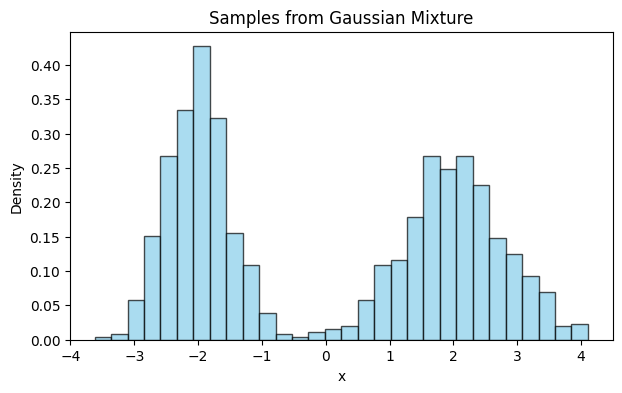

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(x, bins=30,density=True, alpha=0.7, color="skyblue", edgecolor="black")
ax.set_title("Samples from Gaussian Mixture")
ax.set_xlabel("x")
ax.set_ylabel("Density")

plt.show()

In [4]:
class SplineModel(nn.Module):
    def __init__(self, Bins=8, Boundary=3.0):
        super().__init__()
        self.Bins = Bins
        self.Boundary = float(Boundary)

        self.raw_widths = nn.Parameter(torch.ones(Bins))
        self.raw_heights = nn.Parameter(torch.ones(Bins))
        self.raw_internal_derivatives = nn.Parameter(torch.ones(Bins - 1))

    def valid_params(
        self,
        min_bin_width=1e-3,
        min_bin_height=1e-3,
        min_derivative=1e-3,
    ):
        total = 2.0 * self.Boundary
        if self.Bins * min_bin_width >= total:
            raise ValueError("Bins * min_bin_width must be < 2 * Boundary")
        if self.Bins * min_bin_height >= total:
            raise ValueError("Bins * min_bin_height must be < 2 * Boundary")

        wk = torch.softmax(self.raw_widths, dim=0)
        hk = torch.softmax(self.raw_heights, dim=0)

        wk = min_bin_width + (total - self.Bins * min_bin_width) * wk
        hk = min_bin_height + (total - self.Bins * min_bin_height) * hk

        internal = F.softplus(self.raw_internal_derivatives) + min_derivative

        d0 = torch.ones(1, device=wk.device, dtype=wk.dtype)
        dN = torch.ones(1, device=wk.device, dtype=wk.dtype)
        deltak = torch.cat([d0, internal, dN], dim=0)

        return wk, hk, deltak

    def knot_params(self):
        wk, hk, deltak = self.valid_params()

        xk = torch.cat(
            [
                wk.new_tensor([-self.Boundary]),
                -self.Boundary + torch.cumsum(wk, dim=0),
            ],
            dim=0,
        )
        yk = torch.cat(
            [
                hk.new_tensor([-self.Boundary]),
                -self.Boundary + torch.cumsum(hk, dim=0),
            ],
            dim=0,
        )
        return xk, yk, wk, hk, deltak

    @staticmethod
    def _base_log_prob(u):
        return -0.5 * (u ** 2 + math.log(2.0 * math.pi))

    def forward(self, u):
        original_shape = u.shape
        u = u.reshape(-1)

        x = u.clone()
        logabsdet = torch.zeros_like(u)

        xk, yk, wk, hk, deltak = self.knot_params()
        B = self.Boundary

        inside = (u > -B) & (u < B)
        if inside.any():
            u_in = u[inside]

            bin_idx = torch.searchsorted(xk[1:-1].detach(), u_in.detach())
            x_left = xk[bin_idx]
            y_left = yk[bin_idx]
            widths = wk[bin_idx]
            heights = hk[bin_idx]
            d_left = deltak[bin_idx]
            d_right = deltak[bin_idx + 1]

            s = heights / widths
            xi = (u_in - x_left) / widths
            one_minus_xi = 1.0 - xi

            denom = s + (d_right + d_left - 2.0 * s) * xi * one_minus_xi
            numer = heights * (s * xi.pow(2) + d_left * xi * one_minus_xi)
            x_in = y_left + numer / denom

            deriv_numer = s.pow(2) * (
                d_right * xi.pow(2) + 2.0 * s * xi * one_minus_xi + d_left * one_minus_xi.pow(2)
            )
            deriv = deriv_numer / denom.pow(2)

            x[inside] = x_in
            logabsdet[inside] = torch.log(deriv)

        return x.reshape(original_shape), logabsdet.reshape(original_shape)

    def inverse(self, x):
        original_shape = x.shape
        x = x.reshape(-1)

        u = x.clone()
        logabsdet = torch.zeros_like(x)

        xk, yk, wk, hk, deltak = self.knot_params()
        B = self.Boundary

        inside = (x > -B) & (x < B)
        if inside.any():
            x_in = x[inside]

            bin_idx = torch.searchsorted(yk[1:-1].detach(), x_in.detach())
            x_left = xk[bin_idx]
            y_left = yk[bin_idx]
            widths = wk[bin_idx]
            heights = hk[bin_idx]
            d_left = deltak[bin_idx]
            d_right = deltak[bin_idx + 1]

            s = heights / widths

            a = heights * (s - d_left) + (x_in - y_left) * (d_right + d_left - 2.0 * s)
            b = heights * d_left - (x_in - y_left) * (d_right + d_left - 2.0 * s)
            c = -s * (x_in - y_left)

            discriminant = b.pow(2) - 4.0 * a * c
            discriminant = torch.clamp(discriminant, min=0.0)
            sqrt_disc = torch.sqrt(discriminant)

            xi_quadratic = (2.0 * c) / (-b - sqrt_disc + 1e-12)
            xi_linear = -c / (b + 1e-12)
            xi = torch.where(torch.abs(a) > 1e-10, xi_quadratic, xi_linear)
            xi = torch.clamp(xi, 0.0, 1.0)

            one_minus_xi = 1.0 - xi
            u_in = x_left + xi * widths

            denom = s + (d_right + d_left - 2.0 * s) * xi * one_minus_xi
            deriv_numer = s.pow(2) * (
                d_right * xi.pow(2) + 2.0 * s * xi * one_minus_xi + d_left * one_minus_xi.pow(2)
            )
            forward_deriv = deriv_numer / denom.pow(2)

            u[inside] = u_in
            logabsdet[inside] = -torch.log(forward_deriv)

        return u.reshape(original_shape), logabsdet.reshape(original_shape)

    def log_prob(self, x):
        u, logabsdet = self.inverse(x)
        return self._base_log_prob(u) + logabsdet

    def nll(self, x):
        return -self.log_prob(x).mean()

    def sample(self, n, device=None):
        if device is None:
            device = self.raw_widths.device
        u = torch.randn(n, device=device)
        x, _ = self.forward(u)
        return x



In [5]:
def train_flow(
    model,
    data,
    steps=5000,
    batch_size=256,
    lr=1e-3,
    grad_clip=5.0,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = data.shape[0]

    for step in range(1, steps + 1):
        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]

        loss = model.nll(batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        if step % 500 == 0 or step == 1:
            print(f"step={step:5d}  nll={loss.item():.4f}")

    return model


In [6]:
@torch.no_grad()
def check_inverse_consistency(model, num_points=1000):
    device = model.raw_widths.device
    u = torch.linspace(-5, 5, num_points, device=device)
    x, _ = model.forward(u)
    u_rec, _ = model.inverse(x)
    max_err = (u - u_rec).abs().max().item()
    print(f"max inverse error: {max_err:.6e}")



step=    1  nll=3.2104
step=  500  nll=2.1231
step= 1000  nll=1.8981
step= 1500  nll=1.8821
step= 2000  nll=1.9098
step= 2500  nll=1.8356
step= 3000  nll=1.8584
step= 3500  nll=1.7369
step= 4000  nll=2.0634
step= 4500  nll=1.8346
step= 5000  nll=1.6754
max inverse error: 1.907349e-06
final train nll: 1.8284


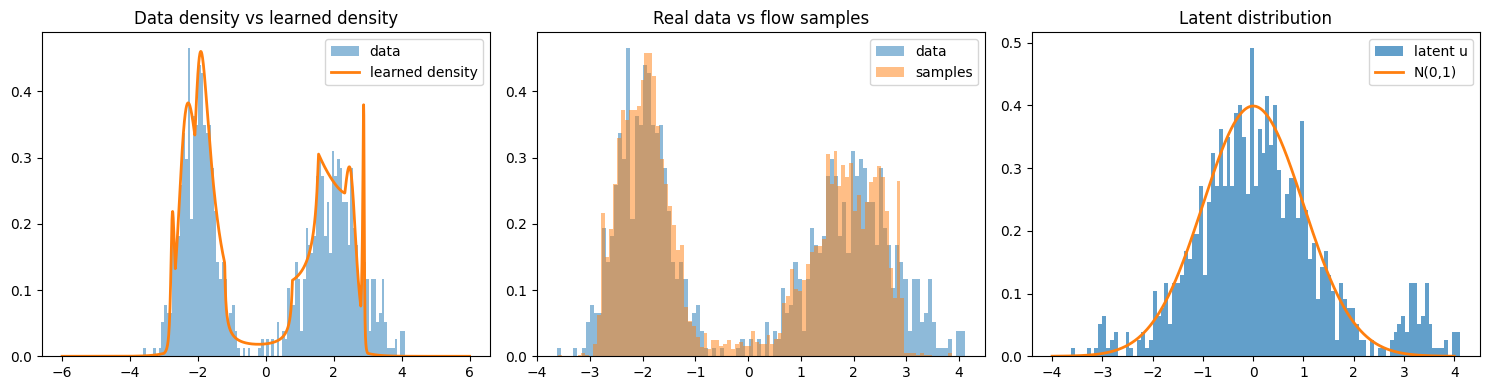

In [7]:
@torch.no_grad()
def plot_results(model, data, num_samples=5000):
    device = data.device

    samples = model.sample(num_samples, device=device)
    u_data, _ = model.inverse(data)

    grid = torch.linspace(-6, 6, 2000, device=device)
    log_px = model.log_prob(grid)
    px = torch.exp(log_px)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(data.cpu().numpy(), bins=100, density=True, alpha=0.5, label="data")
    axes[0].plot(grid.cpu().numpy(), px.cpu().numpy(), lw=2, label="learned density")
    axes[0].set_title("Data density vs learned density")
    axes[0].legend()

    axes[1].hist(data.cpu().numpy(), bins=100, density=True, alpha=0.5, label="data")
    axes[1].hist(samples.cpu().numpy(), bins=100, density=True, alpha=0.5, label="samples")
    axes[1].set_title("Real data vs flow samples")
    axes[1].legend()

    axes[2].hist(u_data.cpu().numpy(), bins=100, density=True, alpha=0.7, label="latent u")
    normal_grid = torch.linspace(-4, 4, 1000)
    normal_pdf = torch.exp(-0.5 * normal_grid**2) / math.sqrt(2.0 * math.pi)
    axes[2].plot(normal_grid.numpy(), normal_pdf.numpy(), lw=2, label="N(0,1)")
    axes[2].set_title("Latent distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_data = torch.tensor(X).to(device=device)

    model = SplineModel(Bins=8, Boundary=3.0).to(device)

    train_flow(
        model,
        train_data,
        steps=5000,
        batch_size=256,
        lr=1e-3,
        grad_clip=5.0,
    )

    check_inverse_consistency(model)

    with torch.no_grad():
        train_nll = model.nll(train_data).item()
        print(f"final train nll: {train_nll:.4f}")

    plot_results(model, train_data)


if __name__ == "__main__":
    main()